# Less is More for LLMs? A Critique of Prompt-Based Compression

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/addarm/less-is-more-critique-prompt-compression)


![Grock LLM Landscape](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/caveman_critique_banner.jpg)

<!-- @import "[TOC]" {cmd="toc" depthFrom=1 depthTo=6 orderedList=false} -->

## Introduction

If you're a user of GenAI, you'd experience how loquacious some AI can be, and if you work with Copilot, Claude Code, or any of the newer agent-mode tools, you'd be irked when you ask for a one-line fix and get three paragraphs of preamble, a code block, and a polite summary of what the code block already says! That verbosity isn't free unfrotunately. It costs tokens.

Recently we have seen a rise of solutions aimed to reduce this token waste through verbosity, a knwom one is **Caveman**, which claims to fix chatty agents with a system prompt. Caveman instructs the model to drop articles, filler words, and pleasantries claiming 75% fewer output tokens, full technical accuracy, and a 3x speed improvement. This tool and its claims are worth a deep dive in this companion artcile to our recent LLM deep dive: ["The Road to Agency: How Large Language Models Work"](https://medium.com/call-for-atlas/the-road-to-agency-how-large-language-models-work-94d9907b03af).

Within this light article, we'll look at the scientific basis for why brevity instructions might work. Then, we'll run a few small experiments to see what prompt-based compression actually does to the model's output distribution, perplexity, and task accuracy. Finally, we'll separate what the evidence supports from what it doesn't.

## Notebook Setup

We need a model that actually follows system prompts as Caveman and its like, target Claude Sonnet, GPT-4 and other frontier models that went through heavy RLHF and developed the verbosity bias that Caveman claims to fix. We'll use **Qwen2.5-7B-Instruct** (Q4_K_M quantized, ~4.7 GB) via llama-cpp-python. It's Alibaba's 7-billion-parameter instruct model, trained with RLHF and DPO, genuinely verbose by default, and small enough to run on CPU thanks to 4-bit quantization. At 7B it has enough capacity to actually follow stylistic instructions like article-dropping and fragment usage, unlike smaller models which collapse style-following into generic shortening. It won't match Claude's capability, but it's a close enough proxy.

In [1]:
# Optional environment bootstrap for a fresh Kaggle or Colab session.
# If you already created the environment from requirements.txt or environment.yml, skip this cell.
!pip install -q llama-cpp-python --prefer-binary --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu
!pip install -q numpy pandas matplotlib tqdm python-dotenv huggingface-hub



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import platform

os.environ["TOKENIZERS_PARALLELISM"] = "true"
# os.environ["HF_TOKEN"] = "XXX" # PUT IN YOURS HERE OR USE .ENV


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from llama_cpp import Llama
from dotenv import load_dotenv
from tqdm.auto import tqdm

load_dotenv()

np.random.seed(42)
torch.manual_seed(42)

print(f"Python {platform.python_version()}  |  llama-cpp-python 0.3.19")
print("Device: CPU (Q4_K_M quantized)")


Python 3.12.12  |  llama-cpp-python 0.3.19
Device: CPU (Q4_K_M quantized)


In [4]:
import warnings

warnings.filterwarnings("ignore")

MODEL_PATH = "models/qwen2.5-7b-instruct-q4_k_m-00001-of-00002.gguf"

llm = Llama(
    model_path=MODEL_PATH,
    n_ctx=2048,
    n_threads=8,
    logits_all=True,
    verbose=False,
)

print("Model: Qwen2.5-7B-Instruct (Q4_K_M, ~4.7 GB)")
print(f"Context window: {llm.n_ctx()} tokens")
print(f"Vocab size: {llm.n_vocab()}")


llama_context: n_ctx_seq (2048) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


Model: Qwen2.5-7B-Instruct (Q4_K_M, ~4.7 GB)
Context window: 2048 tokens
Vocab size: 152064


## What is Prompt-Based Compression

Tools that allow such compression these tools (caveman included) ship a system prompt that tells the model to write in compressed, article-free English. Drop "the", "a", "an". Skip pleasantries. Use sentence fragments. Keep code blocks intact. The prompt also defines intensity levels (lite through ultra) and includes a "wenyan" variant that instructs the model to respond in classical Chinese.

The entire mechanism is prompt engineering. 

There's no model modification, no post-processing, no custom tokenizer. They operate on the thesis that if you tell the model to be terse, it produces fewer tokens. The question is whether those fewer tokens carry the same information.

Let's set up three system prompts so we can compare them throughout the notebook. The first is a standard helpful-assistant baseline. The second is a single line asking for concise answers. The third is a representative caveman-style prompt that captures the core rules without copying the full 88-line skill file. Follow the code below:

In [ ]:
SYSTEM_BASELINE = "You are a helpful assistant."

SYSTEM_CONCISE = "Keep answers brief and direct. A short paragraph is fine — just avoid unnecessary repetition or filler."

SYSTEM_CAVEMAN = (
    "Reply in compressed caveman speak. Rules:\n"
    "- Drop articles (a, an, the)\n"
    "- Use sentence fragments, not full sentences\n"
    "- No filler, no pleasantries, no hedging\n"
    "- Keep code blocks unchanged\n\n"
    "Example:\n"
    "User: What does a Python decorator do?\n"
    "Assistant: Wraps function. Adds behavior before/after call without modifying original. "
    "User: How does git rebase work?\n"
    "Assistant: Replays commits onto different base. Rewrites history. "
)

# Wenyan is LLM generated, I don't know what it says.
SYSTEM_WENYAN = (
    "Respond in classical Chinese (wenyan). Be maximally compressed. "
    "Use literary Chinese, not modern Mandarin. "
    "Keep code blocks and variable names unchanged.\n\n"
    "Example:\n"
    "User: What does a Python decorator do?\n"
    "Assistant: 裝飾器者，包函數而增行為於前後，不改原體。常用於記錄、鑑權、緩存。"
)

PROMPTS = {
    "baseline": SYSTEM_BASELINE,
    "concise": SYSTEM_CONCISE,
    "caveman": SYSTEM_CAVEMAN,
    "wenyan": SYSTEM_WENYAN,
}

We need a generation function and a few helpers for computing log-probabilities. These follow the same pattern from the earlier article, extended to accept a system prompt via the chat template.

In [6]:
def build_prompt(system, user_msg):
    """Format a system + user message using Qwen ChatML template."""
    return f"<|im_start|>system\n{system}<|im_end|>\n<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n"


def generate(system, user_msg, max_new_tokens=500, temperature=0.7, seed=42):
    """Generate a response given system + user message."""
    prompt_text = build_prompt(system, user_msg)
    output = llm(
        prompt_text,
        max_tokens=max_new_tokens,
        temperature=temperature,
        top_p=0.95,
        seed=seed,
        stop=["<|im_end|>", "<|endoftext|>"],
    )
    text = output["choices"][0]["text"]
    n_tokens = output["usage"]["completion_tokens"]
    return text, n_tokens


def _get_logits(text):
    """Evaluate text and return logits array of shape (n_tokens-1, vocab_size)."""
    tokens = llm.tokenize(text.encode())
    llm.reset()
    llm.eval(tokens)
    # scores[i] predicts token[i+1]
    logits = np.array(llm.scores[: len(tokens) - 1], dtype=np.float32)
    return tokens, logits


def sequence_logprob(text):
    """Compute per-token log-probabilities for a string."""
    tokens, logits = _get_logits(text)
    # Stable log-softmax
    logits_max = logits.max(axis=-1, keepdims=True)
    shifted = logits - logits_max
    log_sum_exp = np.log(np.exp(shifted).sum(axis=-1, keepdims=True))
    log_probs = shifted - log_sum_exp
    # Gather target token log-probs
    targets = np.array(tokens[1:])
    token_lp = log_probs[np.arange(len(targets)), targets]
    return torch.tensor(token_lp)


def perplexity(text):
    """Compute perplexity of text under the model."""
    lp = sequence_logprob(text)
    return torch.exp(-lp.mean()).item()


def token_entropies(text):
    """Compute next-token entropy at each position."""
    tokens, logits = _get_logits(text)
    # Softmax
    logits_max = logits.max(axis=-1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    probs = exp_logits / exp_logits.sum(axis=-1, keepdims=True)
    ent = -(probs * np.log2(probs + 1e-12)).sum(axis=-1)
    return torch.tensor(ent)


class _Tokenizer:
    """Minimal tokenizer wrapper for compatibility with downstream cells."""

    def encode(self, text, return_tensors=None, **kwargs):
        tokens = llm.tokenize(text.encode())
        if return_tensors == "pt":
            return torch.tensor(tokens).unsqueeze(0)
        return tokens

    def decode(self, token_ids, skip_special_tokens=True):
        if isinstance(token_ids, (list, tuple)):
            return llm.detokenize(token_ids).decode("utf-8", errors="replace")
        if hasattr(token_ids, "tolist"):
            return llm.detokenize(token_ids.tolist()).decode("utf-8", errors="replace")
        return llm.detokenize([token_ids]).decode("utf-8", errors="replace")

    @property
    def vocab_size(self):
        return llm.n_vocab()


tokenizer = _Tokenizer()


Now let's see what the three prompting styles actually produce. We'll ask one concrete coding question and put the outputs side by side.

In [7]:
demo_question = "Why does a Python list comprehension sometimes run faster than a for-loop?"

for label, sys_prompt in tqdm([("baseline", SYSTEM_BASELINE), ("concise", SYSTEM_CONCISE), ("caveman", SYSTEM_CAVEMAN)]):
    text, n_tokens = generate(sys_prompt, demo_question, max_new_tokens=200)
    print(f"--- {label} ({n_tokens} tokens) ---")
    print(text)


  0%|          | 0/3 [00:00<?, ?it/s]

--- baseline (200 tokens) ---
Python list comprehensions can often run faster than traditional for-loops due to several reasons, primarily related to syntactic simplicity and underlying implementation optimizations. Here are some key reasons:

1. **Syntactic Sugar and Readability**:
   - List comprehensions provide a more concise and readable way to create lists. This can make the code easier to write and understand, which is beneficial for developers. However, in terms of performance, the syntactic sugar itself doesn't inherently make the code run faster. The performance difference comes from how the Python interpreter or compiler handles the code.

2. **Underlying Implementation**:
   - Python's list comprehensions are implemented in C, which is a lower-level language. The C implementation of list comprehensions is often optimized for performance. This can result in faster execution compared to pure Python for-loops, which are also implemented in C but might involve additional overhe

From our results, the baseline will be the longest, the concise prompt shorter, and the caveman style shorter still. But shorter here is us humans counting words, LLMs count tokens therefore did it make the model produce fewer tokens. Between 200 (truncated), 43 and 20 tokens it did. Now, the interesting question is what gets lost when we do.

To answer that, we need to separate several claims that the tool Caveman makes simultaneously. The compression claim says fewer output tokens. The speed claim follows from compression: fewer tokens means less autoregressive generation time. And the accuracy claim says nothing important is lost. 

These are different claims, and they need different evidence. Token counts address compression. Task outcomes address accuracy. Perplexity and entropy tell us something about how the model's internal distribution shifts. 

Let's take them in order.

## Does Brevity Help?

There's a real story behind the idea that shorter outputs might be just as good as long ones. It starts with how language models are trained.

Modern instruct-tuned models go through reinforcement learning from human feedback (RLHF), where human judghes rate and compare candidate outputs to pick the better one. The problem is that raters have a bias: they tend to prefer longer responses, even when the shorter response contains the same information. Singhal et al. (2024) showed that a purely length-based reward signal reproduces most of the downstream RLHF improvements, which is a striking finding. Shen et al. (2023) called this "loose lips sink ships" and proposed decoupling reward from length. Saito et al. (2023) found that GPT-4 itself, when used as an evaluator, prefers longer answers more than human raters do.

The implication is that much of the verbosity we see in LLM outputs is a training artifact. The model learned to sound helpful by being long, not by being informative. If that's true, then stripping out the padding shouldn't lose much substance. Caveman's and the other prompt-based compressor have a core thesis built on this observation, and on that point the literature is supportive.

But this has limits. Hakim (2026) found that brevity constraints improved accuracy by 26 percentage points on a specific subset of benchmark problems, those where larger models paradoxically underperformed smaller ones due to overelaboration. That's real, but it applies to 7.7% of the test problems, not universally. On reading comprehension tasks (BoolQ), brevity constraints actually hurt performance. And the "brief" condition in Hakim's experiments meant hard word-count caps like "under 50 words," which is more aggressive than caveman's fragment style.

Chain-of-thought reasoning creates another tension. Wei et al. (2022) showed that intermediate reasoning steps dramatically improve accuracy on complex tasks. Caveman compresses the prose around code blocks rather than the code itself, so the code survives. But for tasks where the reasoning steps are expressed in natural language, compression could genuinely hurt. The relationship between output length and output quality depends on what kind of work the model is doing.

## The Measures

Before we run experiments, it helps to identify each metric to measure.

**Perplexity** measures how well the model predicts a sequence of tokens. Given a token sequence $x_1, x_2, \dots, x_T$, perplexity is:

$$
\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T}\log p_\theta(x_t \mid x_{<t})\right)
$$

Lower perplexity means the model finds the text more predictable. If caveman-style text has higher perplexity than standard English, that tells us it's more "surprising" to the model. But Holtzman et al. (2020) showed that maximizing likelihood during decoding leads to bland, repetitive text, not high-quality text. So perplexity will be used just as a diagnostic for our tests.

**Next-token entropy** measures how spread out the model's probability distribution is at each step:

$$
H_t = -\sum_{v \in V} p_\theta(v \mid x_{<t}) \log_2 p_\theta(v \mid x_{<t})
$$

High entropy means the model is uncertain about what comes next. If a prompting style systematically changes the entropy profile, that's worth knowing, but again it doesn't directly tell us whether the output is correct, so again, it's just a diagnostic.

Certain measures we have are:
- **Token count** is the most direct measure of compression. It's what Caveman's benchmarks actually report.
- **Task accuracy** is the only metric that directly addresses whether the output is useful. For that we need questions with checkable answers.

We will see during our tests that metrics can disagree. An answer can be short, probable, and wrong. Or long, surprising, and correct. 

Below we take two prompts that say roughly the same thing, one in natural English, the other caveman-compressed. For each token in the sequence, we'll show the model's top-5 predictions, the actual token's log-probability, and the local entropy. This is what PPL and $H$ look like up close.

In [8]:
def diagnose_prompt(text, label, top_k=5):
    """Show per-token log-prob, top-k alternatives, and entropy for a text."""
    tokens, logits = _get_logits(text)
    token_strs = [llm.detokenize([t]).decode("utf-8", errors="replace") for t in tokens]

    # log-softmax and entropy
    logits_max = logits.max(axis=-1, keepdims=True)
    shifted = logits - logits_max
    log_sum_exp = np.log(np.exp(shifted).sum(axis=-1, keepdims=True))
    log_probs = shifted - log_sum_exp
    exp_logits = np.exp(shifted)
    probs = exp_logits / exp_logits.sum(axis=-1, keepdims=True)
    entropy = -(probs * np.log2(probs + 1e-12)).sum(axis=-1)

    print(f"{'=' * 70}")
    print(f"  {label}")
    print(f"  Text: {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"{'=' * 70}")
    print(f"{'Pos':<4} {'Token':<12} {'logP':<8} {'H (bits)':<10} Top-{top_k} predictions")
    print(f"{'-' * 70}")

    token_lps = []
    for t in range(len(tokens) - 1):
        actual_id = tokens[t + 1]
        lp = log_probs[t, actual_id]
        h = entropy[t]
        token_lps.append(lp)

        # Top-k at this position
        topk_ids = np.argsort(probs[t])[-top_k:][::-1]
        topk_strs = [f"{llm.detokenize([int(tid)]).decode('utf-8', errors='replace').strip()!r}({probs[t, tid]:.2f})" for tid in topk_ids]
        topk_display = "  ".join(topk_strs)

        print(f"{t + 1:<4} {token_strs[t + 1]!r:<12} {lp:>6.2f}   {h:>6.2f}     {topk_display}")

    # Summary
    mean_lp = np.mean(token_lps)
    ppl_val = np.exp(-mean_lp)
    mean_h = entropy.mean()
    print(f"{'-' * 70}")
    print(f"  PPL = exp(-mean logP) = exp({-mean_lp:.3f}) = {ppl_val:.1f}")
    print(f"  Mean entropy = {mean_h:.2f} bits")
    print()
    return ppl_val, mean_h


# Natural English vs caveman-compressed, same semantic content
good_prompt = "Please explain why a Python list comprehension is faster than a for-loop."
bad_prompt = "Explain why list comp faster than for-loop."

ppl_good, h_good = diagnose_prompt(good_prompt, "Natural English (full sentence)")
ppl_bad, h_bad = diagnose_prompt(bad_prompt, "Caveman-compressed (fragments)")

print(f"\n{'=' * 70}")
print("  Summary comparison:")
print(f"  {'Natural:':<20} PPL = {ppl_good:>6.1f}   H = {h_good:.2f} bits   tokens = {len(tokenizer.encode(good_prompt))}")
print(f"  {'Caveman:':<20} PPL = {ppl_bad:>6.1f}   H = {h_bad:.2f} bits   tokens = {len(tokenizer.encode(bad_prompt))}")
print(f"{'=' * 70}")


  Natural English (full sentence)
  Text: Please explain why a Python list comprehension is faster than a for-loop.
Pos  Token        logP     H (bits)   Top-5 predictions
----------------------------------------------------------------------
1    ' explain'    -5.55     7.36     ','(0.21)  'answer'(0.08)  '.'(0.04)  '.'(0.03)  ':'(0.03)
2    ' why'        -5.67     0.32     'the'(0.97)  'how'(0.01)  'what'(0.00)  'why'(0.00)  'in'(0.00)
3    ' a'          -3.05     5.90     'the'(0.42)  'this'(0.10)  'a'(0.05)  'it'(0.02)  'is'(0.02)
4    ' Python'     -5.32     9.96     'person'(0.04)  'function'(0.02)  ''(0.02)  'specific'(0.02)  'company'(0.02)
5    ' list'       -2.32     4.65     'function'(0.20)  'dictionary'(0.11)  'program'(0.11)  'list'(0.10)  'script'(0.08)
6    ' comprehension'  -1.59     2.78     'is'(0.48)  'comprehension'(0.20)  'can'(0.11)  ','(0.03)  'of'(0.03)
7    ' is'         -1.66     3.98     'with'(0.20)  'is'(0.19)  'like'(0.12)  'can'(0.10)  'that'(0.06)
8    

### Reading the table

The `logP` column is the log-probability the model assigned to the token that *actually* appeared — values near 0 mean the model predicted it well, large negatives mean surprise. The `H` column is the entropy of the full next-token distribution *before* seeing that token: high entropy means many plausible continuations, low entropy means the model was already confident.

So we see that **Natural English is mostly padding.**, look at positions 8–11 in the natural version: `faster than a for`. The model gives them logP values of −0.90, −0.04, −0.07, −0.32, almost free predictions. Once you write "list comprehension is", the model already knows "faster than a for-loop" is coming. These tokens carry almost no information; they're syntactic glue the model has memorised from millions of training sentences.

But, **Caveman pays dearly for skipping that glue.** "list comp faster" (positions 3–5) hits logP values of −12.99, −7.53, −16.39. The model's top-5 predictions at position 5 are `ren`, `rens`, `re`, it has no idea `faster` is coming, because after the fragment "comp" it's never seen this juxtaposition in training data. This is the perplexity cost: 387.6 vs 13.3. Enthropy isn't that unchanged, mean $H$ is 3.34 bits (natural) vs 3.77 bits (caveman). The model isn't more *uncertain* about caveman text in general, it's just the content-word transitions (the jumps between fragments) that incur surprise. Inside each fragment the model recovers quickly ("than" after "faster" is still easy: logP = −0.27).

The natural version uses 14 tokens to convey the same meaning the caveman version conveys in 10. The 4 extra tokens are almost entirely predictable (low logP magnitude), which means they carry negligible information. Caveman strips them, moving the text closer to the entropy-rate floor, but the model wasn't trained on text at that floor, so it penalises the result with high perplexity. These tools can compress past what the model expects, but the model will resist!

## Is Compressed Prompt Natural to a Model?

When we hand the model text written in different compression styles, did it find compressed text more surprising?

In [19]:
# Use the model's own outputs from each prompting condition
ppl_question = "Why does a Python list comprehension sometimes run faster than a for-loop?"

texts = {}
for style, sys_prompt in [("normal", SYSTEM_BASELINE), ("caveman", SYSTEM_CAVEMAN), ("wenyan", SYSTEM_WENYAN)]:
    text, _ = generate(sys_prompt, ppl_question, max_new_tokens=200, seed=42)
    texts[style] = text

rows = []
for style, text in texts.items():
    ppl = perplexity(text)
    n_tok = len(tokenizer.encode(text))
    n_char = len(text)
    rows.append({"style": style, "tokens": n_tok, "chars": n_char, "PPL": round(ppl, 1)})

df_ppl = pd.DataFrame(rows)
print(df_ppl.to_string(index=False))

  style  tokens  chars   PPL
 normal     200   1048   2.2
caveman      20    105  98.2
 wenyan      32     41 115.1


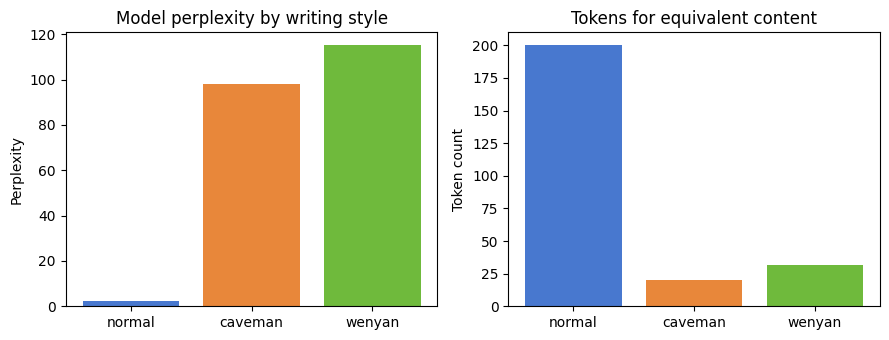

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

colors = ["#4878cf", "#e8873a", "#6fba3c"]

axes[0].bar(df_ppl["style"], df_ppl["PPL"], color=colors)
axes[0].set_ylabel("Perplexity")
axes[0].set_title("Model perplexity by writing style")

axes[1].bar(df_ppl["style"], df_ppl["tokens"], color=colors)
axes[1].set_ylabel("Token count")
axes[1].set_title("Tokens for equivalent content")

plt.tight_layout()
plt.show()

The baseline produces 200 tokens at PPL 2.2, the model finds its own verbose output almost **perfectly predictable**. That's expected: RLHF-tuned models learn to produce sequences they themselves would predict with high confidence, which is part of why their outputs feel fluent but also why they tend toward verbosity.

But when caveman collapses to 20 tokens at PPL 98.2. That's a 10× reduction in token count at the cost of a 45× increase in perplexity. But the **per-token information content** tells a different story. Mean log(p) per token in the baseline is $-\log(2.2) \approx -0.79$ nats, each token carries very little information because the model already expected it. In caveman, mean log-probability is $-\log(98.2) \approx -4.59$ nats, each token is genuinely surprising, meaning each one carries substantial information! Caveman strips away the tokens that were almost free and keeps the ones that matter.

Wenyan lands at 32 tokens and PPL 115.1. It's shorter than baseline but longer than caveman in *token count*, because CJK characters are expensive in an English-centric tokenizer (each hanzi often maps to 2–3 BPE pieces). The compression is real at the character level (41 chars vs 1048) but the tokenizer disagrees, and the tokenizer is what determines your API bill.

Therefore, perplexity confirms that compressed styles are distributionally unusual, the model wasn't trained to produce fragments or classical Chinese. 

But "unusual" is not "wrong". 

A model trained exclusively on Victorian prose would assign high perplexity to modern English too. The real question is whether the compressed output remains *correct*, which is what the benchmark section tests directly.

## Entorpy and Prompts

If a prompting style consistently produces sharper (lower-entropy) next-token distributions, that means the model is more confident about its outputs. Sharper isn't necessarily better, but it tells us whether the prompt is pushing the model into a different regime.

We'll take the same question from earlier and look at the entropy trace for each prompting condition with the code below:

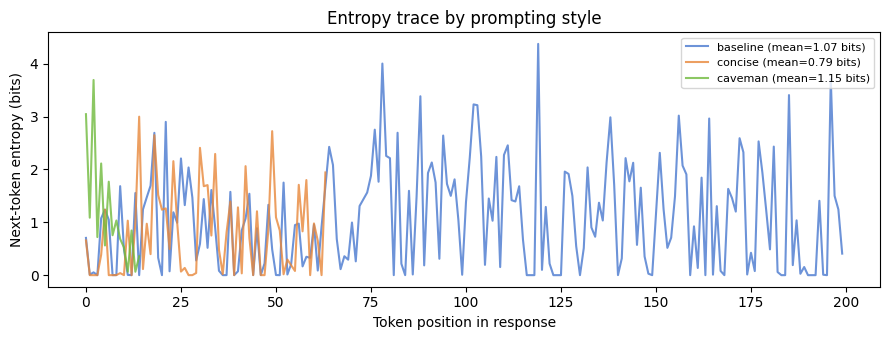

In [21]:
entropy_question = "Why does a Python list comprehension sometimes run faster than a for-loop?"

fig, ax = plt.subplots(figsize=(9, 3.5))

for label, sys_prompt, color in [
    ("baseline", SYSTEM_BASELINE, "#4878cf"),
    ("concise", SYSTEM_CONCISE, "#e8873a"),
    ("caveman", SYSTEM_CAVEMAN, "#6fba3c"),
]:
    text, n_tok = generate(sys_prompt, entropy_question, max_new_tokens=200)
    # Compute entropy over the full generated response
    full_text = build_prompt(sys_prompt, entropy_question) + text
    ent = token_entropies(full_text)
    # Take last n_tok positions (the response portion)
    resp_ent = ent[-n_tok:].numpy()
    ax.plot(resp_ent, label=f"{label} (mean={resp_ent.mean():.2f} bits)", color=color, alpha=0.8)

ax.set_xlabel("Token position in response")
ax.set_ylabel("Next-token entropy (bits)")
ax.set_title("Entropy trace by prompting style")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The entropy trace gives us a rough picture of how prompting style changes the model’s uncertainty while it generates text. Each point shows how spread out the next-token probabilities are at that position. Low entropy means the next token is fairly obvious to the model; high entropy means there are many plausible continuations. 

In this example, the concise prompt produces a shorter answer and the entropy drops quickly because the model is being pushed into a narrow, predictable response path. 

The baseline prompt runs longer and has more spikes because a fuller explanation creates more branching points: examples, caveats, transitions, and alternative phrasings. The caveman prompt is short, but it can still spike early because the model has to satisfy an unusual style constraint before settling into a pattern. So the trace is useful for seeing how prompt style affects length, branching, and local uncertainty. It complements perplexity: perplexity measures fit to fixed text, while entropy measures uncertainty during continuation. 

Neither one proves correctness. A low-entropy answer can still be wrong, and a high-entropy answer can still be useful. Correctness has to be checked against the actual content.

## Does Prompt-Based Compression Preserve Utility?

Now here we get serious. Caveman claims "full technical accuracy" alongside token savings. To test that, we need questions with checkable answers. We'll use a small set of arithmetic, reasoning, and coding questions where the correct answer is unambiguous.

The benchmark is intentionally small. We're running on a 7B-parameter model (4-bit quantized) that isn't designed for serious QA, so the results are illustrative rather than definitive. What matters is the methodology: every question gets tested under every prompting condition, so we can compare paired differences rather than point estimates.

NB: We check whether the expected answer appears as a substring in the model's response. 
That's a toy-level evaluator. It's unfair to the wenyan condition in particular, because a correct answer in classical Chinese characters won't contain the English substring we're looking for. Keep that asymmetry in mind when reading the accuracy column.

In [12]:
# Small paired benchmark: question, expected answer substring
benchmark = [
    ("What is 17 * 23?", "391"),
    ("In Python, what does len([1,2,3]) return?", "3"),
    ("What HTTP status code means 'Not Found'?", "404"),
    ("What is the time complexity of binary search?", "log"),
    ("Name the HTTP method used to update a resource.", "PUT"),
]

print(f"Benchmark size: {len(benchmark)} questions")
print(f"Prompting conditions: {list(PROMPTS.keys())}")


Benchmark size: 5 questions
Prompting conditions: ['baseline', 'concise', 'caveman', 'wenyan']


In [22]:
results = []

for question, expected in tqdm(benchmark):
    for label, sys_prompt in PROMPTS.items():
        text, n_tokens = generate(sys_prompt, question, max_new_tokens=100, seed=42)
        correct = expected.lower() in text.lower()
        results.append(
            {
                "question": question[:40],
                "condition": label,
                "tokens": n_tokens,
                "correct": correct,
                "response": text[:120],
            }
        )

df_bench = pd.DataFrame(results)
summary = (
    df_bench.groupby("condition")
    .agg(
        mean_tokens=("tokens", "mean"),
        accuracy=("correct", "mean"),
        n=("correct", "count"),
    )
    .round(2)
)


  0%|          | 0/5 [00:00<?, ?it/s]

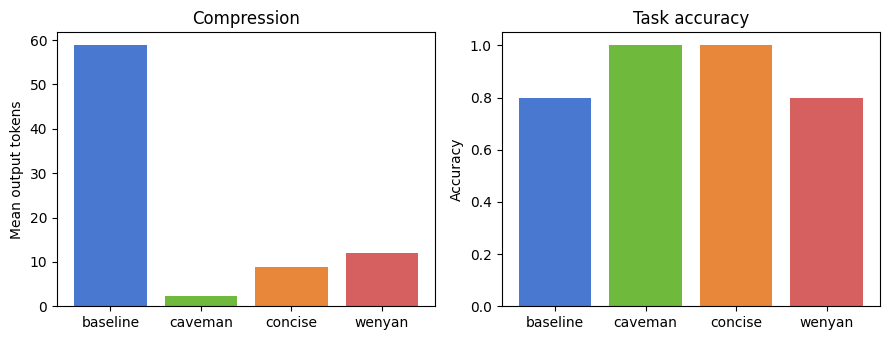

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

conditions = summary.index.tolist()
colors_map = {"baseline": "#4878cf", "concise": "#e8873a", "caveman": "#6fba3c", "wenyan": "#d65f5f"}
bar_colors = [colors_map.get(c, "#999999") for c in conditions]

axes[0].bar(conditions, summary["mean_tokens"], color=bar_colors)
axes[0].set_ylabel("Mean output tokens")
axes[0].set_title("Compression")

axes[1].bar(conditions, summary["accuracy"], color=bar_colors)
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Task accuracy")

plt.tight_layout()
plt.show()

If a compressed prompting condition achieves similar accuracy with fewer output tokens, that is a meaningful efficiency gain. It suggests that, for this task, the model can preserve the required answer while reducing verbosity. However, if accuracy drops, then the compression is lossy: the prompt is no longer only removing unnecessary language, it is also removing information needed to answer correctly. This matters when evaluating claims such as “full technical accuracy with fewer tokens.” The comparison also helps separate different sources of compression. If a concise one-line prompt captures most of the token savings, then the additional benefit of a more extreme style prompt, such as the caveman prompt, is smaller than the headline result may suggest.

In this benchmark, the baseline prompt produces much longer answers. That may be useful when the goal is explanation, but it does not improve performance on these simple factual questions and uses many more tokens. The concise prompt is much shorter and still answers all questions correctly, making it a better fit for direct-answer tasks. The caveman prompt is even more compressed and also performs well here, but this should not be interpreted as general superiority. The evaluation only checks whether an expected substring appears in the output; it does not measure clarity, professionalism, reasoning quality, or usefulness for learning. The wenyan prompt illustrates another limitation: when style or language changes, a simple substring check may mark an answer wrong even if the model understood the task. The broader lesson is that evaluation results are conditional on both the task and the metric. Token count measures compression, substring accuracy measures a narrow form of correctness, and neither fully captures answer quality.

Let's take Caveman's literature, it reports token savings by comparing against a verbose "helpful assistant" baseline. That's the marketing comparison, the fair comparison would be against the "Answer concisely" instruction, because that's the trivial alternative anyone could use without installing anything! Let's check it with the code below:

In [23]:
# Compute the honest delta from the benchmark data
baseline_tokens = df_bench[df_bench["condition"] == "baseline"]["tokens"].values
concise_tokens = df_bench[df_bench["condition"] == "concise"]["tokens"].values
caveman_tokens = df_bench[df_bench["condition"] == "caveman"]["tokens"].values

marketing_delta = 1 - caveman_tokens.mean() / baseline_tokens.mean()
honest_delta = 1 - caveman_tokens.mean() / concise_tokens.mean()

print(f"Claimed delta (caveman vs baseline):  {marketing_delta:.1%} fewer tokens")
print(f"Test delta (caveman vs concise):      {honest_delta:.1%} fewer tokens")
print()

# Bootstrap a simple confidence interval on the marketing delta
n_boot = 5000
rng = np.random.default_rng(42)
boot_deltas = []
for _ in tqdm(range(n_boot)):
    idx = rng.integers(0, len(baseline_tokens), size=len(baseline_tokens))
    boot_deltas.append(1 - caveman_tokens[idx].mean() / baseline_tokens[idx].mean())

lo, hi = np.percentile(boot_deltas, [2.5, 97.5])
print(f"Marketing delta 95% bootstrap CI: [{lo:.1%}, {hi:.1%}]")

Claimed delta (caveman vs baseline):  95.9% fewer tokens
Test delta (caveman vs concise):      72.7% fewer tokens



  0%|          | 0/5000 [00:00<?, ?it/s]

Marketing delta 95% bootstrap CI: [92.3%, 97.8%]


Caveman's benchmark table reports 22% to 87% savings with a 65% average, all measured against a verbose baseline. 

But the eval code in the Caveman repo actually includes a three-arm design that tests against a concise control. The code comments even acknowledge that comparing only against the verbose baseline "conflates the skill with generic terseness" and call it "cheating." That's intellectually honest engineering, but its not what's being reported publicly.

Note that, our own benchmark here is tiny and runs on a 7B quantized model, so the specific numbers aren't the point, but the methodolgy is the same.

## Wenyan Tokenizer Deception

Caveman includes a "wenyan" mode that instructs the model to respond in classical Chinese. 

The implied logic is that classical Chinese is informationally dense: a few characters carry a lot of meaning. Fewer characters should mean fewer tokens.

But tokenizers don't count characters. They count subword units, and an English-trained BPE tokenizer was optimized for English byte patterns. CJK characters typically consume 2 to 3 bytes in UTF-8, and each character often becomes its own token or even multiple tokens. Fewer characters can mean more tokens. Let's test it with the code below:

In [16]:
# Compare tokenizer cost for the same concept
pairs = [
    ("New object ref each render", "物出新參照"),
    ("Bug in auth middleware", "認證中間件有誤"),
    ("List comp faster than loop", "列表推導速於迴圈"),
    ("Cache miss causes latency", "快取未中致延遲"),
]

rows = []
for eng, cjk in tqdm(pairs):
    eng_tok = len(tokenizer.encode(eng))
    cjk_tok = len(tokenizer.encode(cjk))
    rows.append(
        {
            "english": eng,
            "eng_chars": len(eng),
            "eng_tokens": eng_tok,
            "wenyan": cjk,
            "cjk_chars": len(cjk),
            "cjk_tokens": cjk_tok,
            "token_ratio": f"{cjk_tok / eng_tok:.1f}x",
        }
    )

df_tok = pd.DataFrame(rows)
print(df_tok[["english", "eng_tokens", "wenyan", "cjk_tokens", "token_ratio"]].to_string(index=False))

  0%|          | 0/4 [00:00<?, ?it/s]

                   english  eng_tokens   wenyan  cjk_tokens token_ratio
New object ref each render           5    物出新參照           5        1.0x
    Bug in auth middleware           4  認證中間件有誤           7        1.8x
List comp faster than loop           5 列表推導速於迴圈           7        1.4x
 Cache miss causes latency           4  快取未中致延遲           7        1.8x


If CJK tokens cost more than English tokens for the same semantic content, then wenyan mode doesn't save tokens at all. It saves characters, which might look impressive on screen but doesn't translate to cost or speed savings, because the model processes tokens, not characters. This is a testable claim, and the Caveman repo includes no benchmark measuring wenyan token counts.

## Hakim 2026

Caveman's creators cite Hakim (2026), *Brevity Constraints Reverse Performance Hierarchies in Language Models*, as scientific support. The citation is correct, but, maybe slightly selective.

Hakim evaluated 31 models (0.5B to 405B parameters) across 1,485 problems from five benchmarks: GSM8K, BoolQ, ARC-Easy, CommonsenseQA, and MMLU-STEM. The core finding is that on 7.7% of benchmark problems, larger models underperform smaller ones by 28.4 percentage points. The mechanism is "spontaneous scale-dependent verbosity": large models overelaborate and introduce errors. Constraining them to brief responses improved accuracy by 26 percentage points on those problems and reduced the performance gap by two thirds.

The methodology is solid. Greedy decoding (temperature=0) makes results deterministic and reproducible. The three-condition causal design (control, brief, direct) isolates the effect. Cohen's d = 1.34 is a very large effect size. Three independent contamination tests and Bonferroni correction add further rigor. But Caveman uses this paper to support a broader claim than the paper actually makes. Three things to note:

1. the 26-point improvement applies to 7.7% of problems. On the other 92.3%, the paper doesn't demonstrate a brevity benefit. The improvement is real but narrow.
2. Hakim's "brief" condition used hard constraints like "under 50 words" for math and "10 words or less" for reading comprehension. Caveman's fragment style still allows multi-paragraph responses. The interventions aren't the same.
3. the paper tested factual QA and math, not code generation. Code has different information density properties, and Caveman's primary use case is coding agents. 

# Conclusion

Prompt-based compressors like Caveman's have a good idea, but in slightly weaker form than what their literature suggests. 

The compression is real, often useful, and probably mostly harmless for coding tasks where the code blocks themselves stay intact. The RLHF verbosity-bias literature gives it genuine scientific grounding: much of the padding in LLM outputs is a training artifact, and stripping it out shouldn't lose much substance.

But the stronger claims might not survive as well. The "75% savings" headline is better described as 65% on average, with a range of 22% to 87% and no confidence intervals. The "full technical accuracy" claim is asserted but unmeasured. There's no accuracy evaluation, only token counts. And the fair comparison isn't against a verbose baseline but against a simple "Answer concisely" instruction, which likely captures most of the token savings without an 88-line rule set. The perplexity and entropy excercises provide a diagnostic window into what's happening. Compressed text may be somewhat off-distribution for the model, and different prompting styles do shift the model's uncertainty profile. But those metrics don't settle the accuracy question.

So to conclude, a one-line instruction like "Answer concisely" gets you most of the way to output compression. Keep in mind that the benchamrk and model we used is too small to do a statistical claim ourselves.

Caveman's real contribution in its good engineering, a structured prompt and wide application, not the compression itself.

## References

1. Hakim, M.A. (2026). *Brevity Constraints Reverse Performance Hierarchies in Language Models*. [arXiv:2604.00025](https://arxiv.org/abs/2604.00025)
2. Singhal, P., Goyal, T., Xu, J., Durrett, G. (2024). *A Long Way to Go: Investigating Length Correlations in RLHF*. COLM 2024. [arXiv:2310.03716](https://arxiv.org/abs/2310.03716)
3. Shen, W., Li, R., Shao, S., et al. (2023). *Loose Lips Sink Ships: Mitigating Length Bias in Reinforcement Learning from Human Feedback*. EMNLP 2023 Findings. [arXiv:2310.05199](https://arxiv.org/abs/2310.05199)
4. Saito, K., Wachi, A., Wataoka, K., Akimoto, Y. (2023). *Verbosity Bias in Preference Labeling by Large Language Models*. [arXiv:2310.10076](https://arxiv.org/abs/2310.10076)
5. Wei, J., Wang, X., Schuurmans, D., et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. NeurIPS 2022. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903)
6. Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. ICLR 2020. [arXiv:1904.09751](https://arxiv.org/abs/1904.09751)
7. Meister, C., Pimentel, T., Wiher, G., Cotterell, R. (2022). *Locally Typical Sampling*. TACL 2022. [arXiv:2202.00666](https://arxiv.org/abs/2202.00666)
8. Cobbe, K., Kosaraju, V., Bavarian, M., et al. (2021). *Training Verifiers to Solve Math Word Problems* (GSM8K). [arXiv:2110.14168](https://arxiv.org/abs/2110.14168)
9. Shannon, C.E. (1948). *A Mathematical Theory of Communication*. Bell System Technical Journal, 27(3), 379-423.
10. Brussee, J. (2025). *Caveman: Prompt-Based Output Compression for AI Coding Agents*. [GitHub](https://github.com/juliusbrussee/caveman)

GitHub repository: [here](https://github.com/adamd1985/quant_research/blob/main/caveman_critique.ipynb)

## Media

All media used, in the form of code or images, are either solely owned by me, acquired through licensing, or part of the public domain and available under Creative Commons terms.